# Paper Figures — HESS Publication

This notebook generates the publication-quality figures for:
> Connelly et al. — *An algorithmic framework to ascertain and compare mechanical properties from common snowpit observations* — HESS

## Figures produced here

| Figure | File | Section |
|--------|------|---------|
| Fig. 3 | `figures/fig03_coverage.png` | §3.1 — Coverage overview (all pathways) |

## Figures produced in individual notebooks
| Figure | File | Notebook |
|--------|------|----------|
| Fig. 4 | `figures/fig04_density_distributions.png` | `all_density_pathways.ipynb` |
| Fig. 5 | `figures/fig05_emod_distributions.png` | `all_e_mod_pathways.ipynb` |
| Fig. 6 | `figures/fig06_nu_distributions.png` | `all_poissons_ratio_pathways.ipynb` |
| Fig. 7 | `figures/fig07_D11_distributions.png` | `all_D11_pathways.ipynb` |

## HESS figure requirements
- Format: PNG at 300 dpi (or PDF/EPS for vector)
- Minimum width: 8 cm (3.15 in); single col = 3.35 in; double col = 7.0 in
- Color: Wong (2011) colorblind-safe palette
- Font: sans-serif (Helvetica / Arial / DejaVu Sans), all embedded
- No embedded titles — captions go in the `.tex` file
- Legend self-contained within each figure
- Test with Coblis before submission

## Data source
This notebook re-runs the calculations needed for Fig. 3 from scratch to collect
layer-level and slab-level coverage across all parameters and pathways.
**Prerequisite**: run the individual pathway notebooks first to generate Figs. 4–7
(though they are independent — the coverage data is recomputed here).

In [1]:
from pathlib import Path
from typing import Dict, Any
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from snowpyt_mechparams.snowpilot import parse_caaml_directory
from snowpyt_mechparams.data_structures import Pit, Slab
from snowpyt_mechparams.graph import graph
from snowpyt_mechparams.algorithm import find_parameterizations
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.execution.config import ExecutionConfig

## HESS figure style

In [2]:
# ── HESS figure settings ──────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
})

SINGLE_COL = 3.35   # inches (≈ 8.5 cm)
DOUBLE_COL = 7.0    # inches (≈ 17.8 cm)
DPI = 300

# ── Wong (2011) colorblind-safe method colors — consistent across all figures ──
DENSITY_COLORS = {
    'kim_jamieson_table2': '#009E73',   # bluish green
    'geldsetzer':          '#0072B2',   # blue
    'kim_jamieson_table5': '#E69F00',   # orange
    'data_flow':           '#CC79A7',   # reddish purple
}
EMOD_COLORS = {
    'wautier':   '#009E73',
    'kochle':    '#0072B2',
    'bergfeld':  '#E69F00',
    'schottner': '#D55E00',
}
NU_COLORS = {
    'kochle':    '#0072B2',
    'srivastava':'#E69F00',
}

DENSITY_LABELS = {
    'kim_jamieson_table2': 'Kim & Jamieson (2014) T2',
    'geldsetzer':          'Geldsetzer & Jamieson (2000)',
    'kim_jamieson_table5': 'Kim & Jamieson (2014) T5',
    'data_flow':           'Direct measurement',
}
EMOD_LABELS = {
    'wautier':   'Wautier et al. (2015)',
    'kochle':    'Köchle & Schneebeli (2014)',
    'bergfeld':  'Bergfeld et al. (2023)',
    'schottner': 'Schöttner et al. (2026)',
}
NU_LABELS = {
    'kochle':    'Köchle & Schneebeli (2014)',
    'srivastava':'Srivastava et al. (2016)',
}

print("HESS style configured.")

HESS style configured.


## 1. Load snow pit data

In [3]:
snow_pits_raw = parse_caaml_directory(str(Path("data")))
pits = [Pit.from_snow_pit(sp) for sp in snow_pits_raw]

layer_infos = []
for pit in pits:
    try:
        angle = float(pit.slope_angle) if pit.slope_angle is not None and not np.isnan(pit.slope_angle) else 0.0
    except (TypeError, ValueError):
        angle = 0.0
    for idx, layer in enumerate(pit.layers):
        layer_infos.append((layer, angle, pit.pit_id, idx))

# ECTP slabs
ectp_slabs = []
for pit in pits:
    for slab in pit.create_slabs(weak_layer_def="ECTP_failure_layer"):
        ectp_slabs.append({'slab': slab, 'n_layers': len(slab.layers)})

total_layers = len(layer_infos)
total_slabs  = len(ectp_slabs)

print(f"Loaded {len(pits):,} pits, {total_layers:,} layers, {total_slabs:,} ECTP slabs")

Loaded 51,138 pits, 377,729 layers, 14,951 ECTP slabs


## 2. Compute layer-level coverage for density, E-mod, and ν

In [4]:
engine = ExecutionEngine(graph)
config = ExecutionConfig(include_method_uncertainty=False)

# --- Layer-level coverage: density ---
density_pathways = find_parameterizations(graph, graph.get_node("density"))
density_layer_cov: Dict[str, int] = {}

for layer, angle, pit_id, layer_idx in layer_infos:
    slab = Slab(layers=[layer], angle=angle, pit_id=pit_id)
    results = engine.execute_all(slab, "density", config=config)
    for pathway_result in results.pathways.values():
        method = pathway_result.methods_used.get('density', 'unknown')
        ok = any(t.parameter == 'density' and t.success and t.output is not None
                 for t in pathway_result.computation_trace)
        if ok:
            density_layer_cov[method] = density_layer_cov.get(method, 0) + 1

print("Density layer coverage:")
for m, n in sorted(density_layer_cov.items(), key=lambda x: -x[1]):
    print(f"  {m:<30s}: {n:,} / {total_layers:,} ({n/total_layers:.1%})")

Density layer coverage:
  kim_jamieson_table2           : 239,080 / 377,729 (63.3%)
  geldsetzer                    : 203,677 / 377,729 (53.9%)
  kim_jamieson_table5           : 106,370 / 377,729 (28.2%)
  data_flow                     : 10,692 / 377,729 (2.8%)


In [5]:
# --- Layer-level coverage: E-mod (pool across density sub-pathways) ---
emod_layer_cov: Dict[str, set] = {}   # method → set of layer_ids with success

for layer, angle, pit_id, layer_idx in layer_infos:
    layer_id = f"{pit_id}_L{layer_idx}"
    slab = Slab(layers=[layer], angle=angle, pit_id=pit_id)
    results = engine.execute_all(slab, "elastic_modulus", config=config)
    for pathway_result in results.pathways.values():
        emod_m = pathway_result.methods_used.get('elastic_modulus', 'unknown')
        ok = any(t.parameter == 'elastic_modulus' and t.success and t.output is not None
                 for t in pathway_result.computation_trace)
        if ok:
            if emod_m not in emod_layer_cov:
                emod_layer_cov[emod_m] = set()
            emod_layer_cov[emod_m].add(layer_id)

print("E-mod layer coverage (pooled across density sub-pathways):")
for m, s in sorted(emod_layer_cov.items(), key=lambda x: -len(x[1])):
    n = len(s)
    print(f"  {m:<12s}: {n:,} / {total_layers:,} ({n/total_layers:.1%})")

E-mod layer coverage (pooled across density sub-pathways):
  wautier     : 221,576 / 377,729 (58.7%)
  schottner   : 184,451 / 377,729 (48.8%)
  kochle      : 116,922 / 377,729 (31.0%)
  bergfeld    : 91,610 / 377,729 (24.3%)


In [6]:
# --- Layer-level coverage: ν (pool across density sub-pathways) ---
nu_layer_cov: Dict[str, set] = {}

for layer, angle, pit_id, layer_idx in layer_infos:
    layer_id = f"{pit_id}_L{layer_idx}"
    slab = Slab(layers=[layer], angle=angle, pit_id=pit_id)
    results = engine.execute_all(slab, "poissons_ratio", config=config)
    for pathway_result in results.pathways.values():
        nu_m = pathway_result.methods_used.get('poissons_ratio', 'unknown')
        ok = any(t.parameter == 'poissons_ratio' and t.success and t.output is not None
                 for t in pathway_result.computation_trace)
        if ok:
            if nu_m not in nu_layer_cov:
                nu_layer_cov[nu_m] = set()
            nu_layer_cov[nu_m].add(layer_id)

print("Poisson's ratio layer coverage (pooled across density sub-pathways):")
for m, s in sorted(nu_layer_cov.items(), key=lambda x: -len(x[1])):
    n = len(s)
    print(f"  {m:<12s}: {n:,} / {total_layers:,} ({n/total_layers:.1%})")

Poisson's ratio layer coverage (pooled across density sub-pathways):
  kochle      : 159,120 / 377,729 (42.1%)
  srivastava  : 114,270 / 377,729 (30.3%)


## 3. Compute slab-level coverage for D11 across all 32 pathways

In [7]:
D11_pathways = find_parameterizations(graph, graph.get_node("D11"))
d11_slab_cov: Dict[str, int] = {}

for info in ectp_slabs:
    slab = info['slab']
    n = info['n_layers']
    results = engine.execute_all(slab, "D11", config=config)
    for pathway_result in results.pathways.values():
        density_m = pathway_result.methods_used.get('density', 'unknown')
        emod_m    = pathway_result.methods_used.get('elastic_modulus', 'unknown')
        nu_m      = pathway_result.methods_used.get('poissons_ratio', 'unknown')
        full      = f"{density_m} \u2192 {emod_m} \u2192 {nu_m}"
        ok = any(t.parameter == 'D11' and t.success and t.output is not None
                 for t in pathway_result.computation_trace)
        if ok:
            d11_slab_cov[full] = d11_slab_cov.get(full, 0) + 1

print(f"D11 slab coverage across {len(D11_pathways)} pathways:")
for pathway, n in sorted(d11_slab_cov.items(), key=lambda x: -x[1])[:10]:
    print(f"  {pathway}: {n:,} / {total_slabs:,} ({n/total_slabs:.1%})")
print(f"  ... (top 10 of {len(d11_slab_cov)} pathways shown)")

D11 slab coverage across 32 pathways:
  geldsetzer → wautier → kochle: 756 / 14,951 (5.1%)
  kim_jamieson_table2 → wautier → kochle: 756 / 14,951 (5.1%)
  geldsetzer → schottner → kochle: 756 / 14,951 (5.1%)
  kim_jamieson_table2 → schottner → kochle: 756 / 14,951 (5.1%)
  geldsetzer → kochle → kochle: 507 / 14,951 (3.4%)
  kim_jamieson_table2 → bergfeld → kochle: 505 / 14,951 (3.4%)
  geldsetzer → bergfeld → kochle: 483 / 14,951 (3.2%)
  geldsetzer → wautier → srivastava: 460 / 14,951 (3.1%)
  geldsetzer → schottner → srivastava: 460 / 14,951 (3.1%)
  kim_jamieson_table2 → wautier → srivastava: 454 / 14,951 (3.0%)
  ... (top 10 of 32 pathways shown)


## 4. Fig. 3 — Coverage overview

Two-panel figure:
- **(a)** Layer-level coverage by method for density, E-mod, and ν (grouped bar chart)
- **(b)** Slab-level D11 coverage across all 32 pathways (dot-and-line, grouped by density method)

Saved as `figures/fig03_coverage.png`.

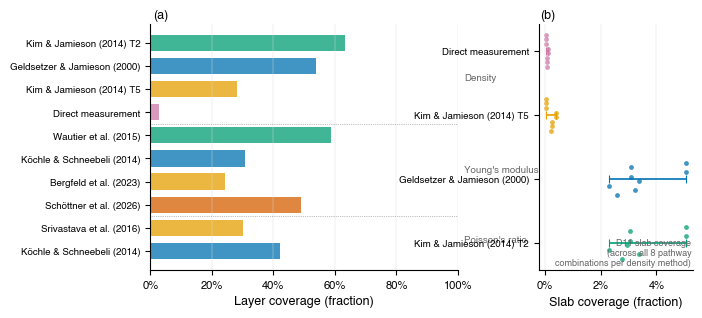

Saved figures/fig03_coverage.png


In [8]:
# ── Panel (a): layer-level coverage grouped by parameter category ─────────
# Collect coverage fractions
density_items  = [(DENSITY_LABELS.get(m, m), density_layer_cov.get(m, 0) / total_layers,
                   DENSITY_COLORS.get(m, '#999999'))
                  for m in ['kim_jamieson_table2', 'geldsetzer', 'kim_jamieson_table5', 'data_flow']]
emod_items     = [(EMOD_LABELS.get(m, m), len(emod_layer_cov.get(m, set())) / total_layers,
                   EMOD_COLORS.get(m, '#999999'))
                  for m in ['wautier', 'kochle', 'bergfeld', 'schottner']]
nu_items       = [(NU_LABELS.get(m, m), len(nu_layer_cov.get(m, set())) / total_layers,
                   NU_COLORS.get(m, '#999999'))
                  for m in ['srivastava', 'kochle']]

# ── Panel (b): slab-level D11 coverage, grouped by density method ─────────
# For each density method, show the range of D11 slab coverage across its pathways
density_methods_order = ['kim_jamieson_table2', 'geldsetzer', 'kim_jamieson_table5', 'data_flow']

d11_by_density: Dict[str, list] = {m: [] for m in density_methods_order}
for pathway, n in d11_slab_cov.items():
    parts = pathway.split(' \u2192 ')
    dm = parts[0] if len(parts) >= 1 else 'unknown'
    if dm in d11_by_density:
        d11_by_density[dm].append(n / total_slabs)

# ── Build two-panel figure ────────────────────────────────────────────────
fig, (ax_a, ax_b) = plt.subplots(
    1, 2, figsize=(DOUBLE_COL, 3.2),
    gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.35}
)

# ── (a) Layer-level bar chart ─────────────────────────────────────────────
all_items   = density_items + emod_items + nu_items
bar_labels  = [it[0] for it in all_items]
bar_vals    = [it[1] for it in all_items]
bar_colors  = [it[2] for it in all_items]

n_bars = len(all_items)
x_pos  = np.arange(n_bars)

bars = ax_a.barh(x_pos[::-1], bar_vals, color=bar_colors, alpha=0.75, height=0.7)

# Group separators and labels
n_density, n_emod, n_nu = len(density_items), len(emod_items), len(nu_items)
sep_positions = [n_bars - n_density - 0.5,
                 n_bars - n_density - n_emod - 0.5]
for sep in sep_positions:
    ax_a.axhline(sep, color='0.5', linewidth=0.5, linestyle=':')

ax_a.set_yticks(x_pos[::-1])
ax_a.set_yticklabels(bar_labels, fontsize=7)
ax_a.set_xlabel('Layer coverage (fraction)')
ax_a.set_xlim(0, 1.0)
ax_a.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.grid(axis='x', linewidth=0.3, color='0.85')

# Group labels on right side
group_centers = [
    n_bars - n_density / 2 - 0.5,
    n_bars - n_density - n_emod / 2 - 0.5,
    n_bars - n_density - n_emod - n_nu / 2 - 0.5,
]
group_names = ['Density', "Young's modulus", "Poisson's ratio"]
for yc, gname in zip(group_centers, group_names):
    ax_a.text(1.02, yc, gname, transform=ax_a.get_yaxis_transform(),
              fontsize=7, rotation=0, va='center', color='0.4')

ax_a.text(0.01, 1.01, '(a)', transform=ax_a.transAxes,
          fontsize=9, fontweight='bold', va='bottom')

# ── (b) Slab-level D11 coverage by density method ────────────────────────
y2_labels = [DENSITY_LABELS.get(m, m) for m in density_methods_order]

for i, dm in enumerate(density_methods_order):
    covs = d11_by_density[dm]
    if not covs:
        continue
    color = DENSITY_COLORS.get(dm, '#999999')
    y_jitter = i + np.linspace(-0.25, 0.25, len(covs))
    ax_b.scatter(covs, y_jitter, color=color, s=12, alpha=0.75, linewidths=0)
    ax_b.errorbar(
        np.mean(covs), i,
        xerr=[[np.mean(covs) - min(covs)], [max(covs) - np.mean(covs)]],
        fmt='none', color=color, linewidth=1.2, capsize=3, capthick=0.8,
    )

ax_b.set_yticks(np.arange(len(density_methods_order)))
ax_b.set_yticklabels(y2_labels, fontsize=7)
ax_b.set_xlabel('Slab coverage (fraction)')
ax_b.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.grid(axis='x', linewidth=0.3, color='0.85')

ax_b.text(0.01, 1.01, '(b)', transform=ax_b.transAxes,
          fontsize=9, fontweight='bold', va='bottom')
ax_b.text(0.99, 0.01,
          f'D11 slab coverage\n(across all 8 pathway\ncombinations per density method)',
          transform=ax_b.transAxes, fontsize=6.5, va='bottom', ha='right', color='0.4')

plt.tight_layout()
plt.savefig('figures/fig03_coverage.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved figures/fig03_coverage.png")

## 5. Evaluate: three-panel option for Figs. 4–6

The figure plan notes a space-saving option: combine Figs. 4 (density), 5 (E-mod), and 6 (ν) into a
single three-panel figure. This cell generates that combined figure for evaluation.
If the panels are individually too dense to read at journal column width, keep them separate.

**Decision**: evaluate after running individual notebooks; choose during revision.

In [9]:
# This cell intentionally left for future consolidation decision.
# It requires density_df, emod_df, and nu_df to be populated by running the
# individual pathway notebooks first (or by copying their data-collection cells here).
# 
# Once the decision is made to combine, the three-panel figure can be built here
# by adapting the figure cells from all_density_pathways.ipynb, 
# all_e_mod_pathways.ipynb, and all_poissons_ratio_pathways.ipynb.
print("Three-panel consolidation deferred until individual figures are reviewed.")

Three-panel consolidation deferred until individual figures are reviewed.
